In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


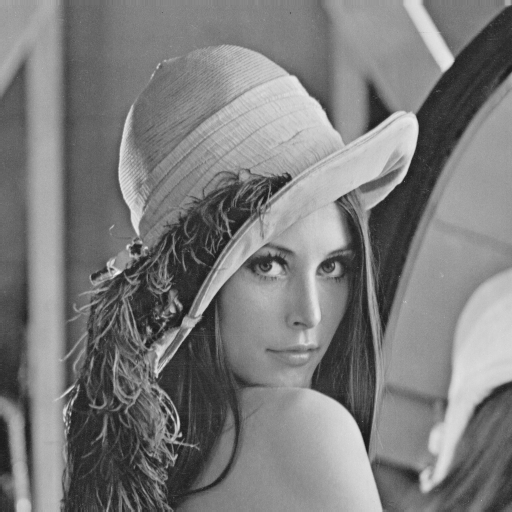

In [2]:
from PIL import Image
image_colored = Image . open ("/content/drive/MyDrive/AI_and_ML/wk5_tut/lena_gray.gif")
image_colored = image_colored . resize (( 512 , 512 ))

display ( image_colored)

In [3]:
import numpy as np
import matplotlib . pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image . open ("/content/drive/MyDrive/AI_and_ML/wk5_tut/lena_gray.gif") . convert ("L")
# Convert to NumPy array
image_array = np . array ( image )
# Get image dimensions
height , width = image_array . shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array . reshape ( height , width )

In [4]:
# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean

In [5]:
# Compute covariance matrix
cov_matrix = np . cov ( centered_data , rowvar = False )

In [6]:
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors indescending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

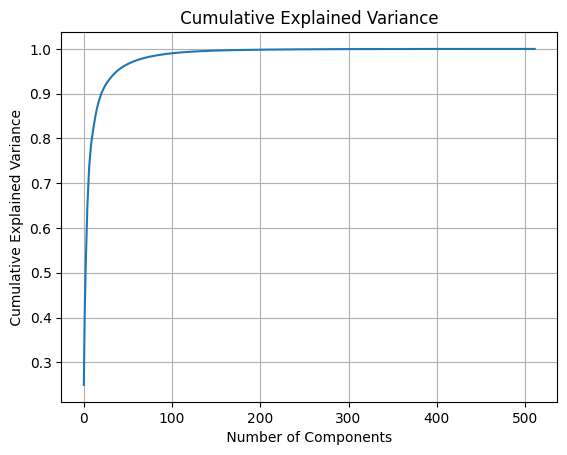

In [7]:
# Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

In [8]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [9]:
# Project the data onto the principal components
compressed_data = np . dot ( centered_data , components )

In [10]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) + mean

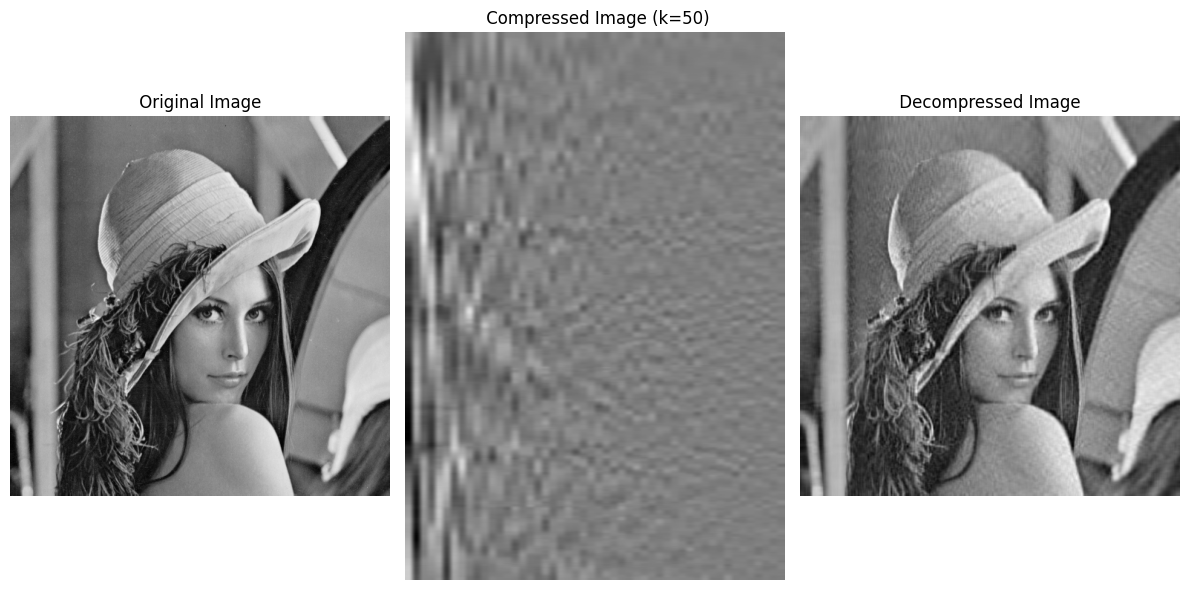

In [11]:
plt . figure ( figsize =(12 , 6) )
# Original Image
plt . subplot (1 , 3 , 1)
plt . imshow ( image_array , cmap ="gray")
plt . title (" Original Image ")
plt . axis ("off")
# Compressed Representation
plt . subplot (1 , 3 , 2)
plt . imshow ( compressed_data , cmap ="gray", aspect ="auto")
plt . title ( f" Compressed Image (k={k})")
plt . axis ("off")
# Decompressed Image
plt . subplot (1 , 3 , 3)
plt . imshow ( decompressed_data , cmap ="gray")
plt . title (" Decompressed Image ")
plt . axis ("off")
plt . tight_layout ()
plt . show ()

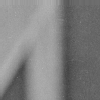

In [12]:
# Define the cropping box (left, upper, right, lower)
left = 0
upper = 0
right = 100
lower = 100

# Crop the image (assign the result!)
cropped_image = image_colored.crop((left, upper, right, lower))

# Display the cropped image
display(cropped_image)

In [22]:
import numpy as np
# Function to apply convolution manually using NumPy
def conv2d_nopadding(image, kernel):
    # Get the dimensions of the image and kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    # No padding is applied (valid padding)
    pad_height = 0
    pad_width = 0
    # Skip padding if pad_height and pad_width are zero
    padded_image = image # No padding
    # Calculate the output dimensions without padding
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1
    output = np.zeros((output_height, output_width))
    # Apply the convolution operation
    for i in range(output_height):
        for j in range(output_width):
            # Extract the region of interest from the image
            region = padded_image[i:i + kernel_height, j:j + kernel_width]
            # Perform element-wise multiplication and sum the result
            output[i, j] = np.sum(region * kernel)
    return output

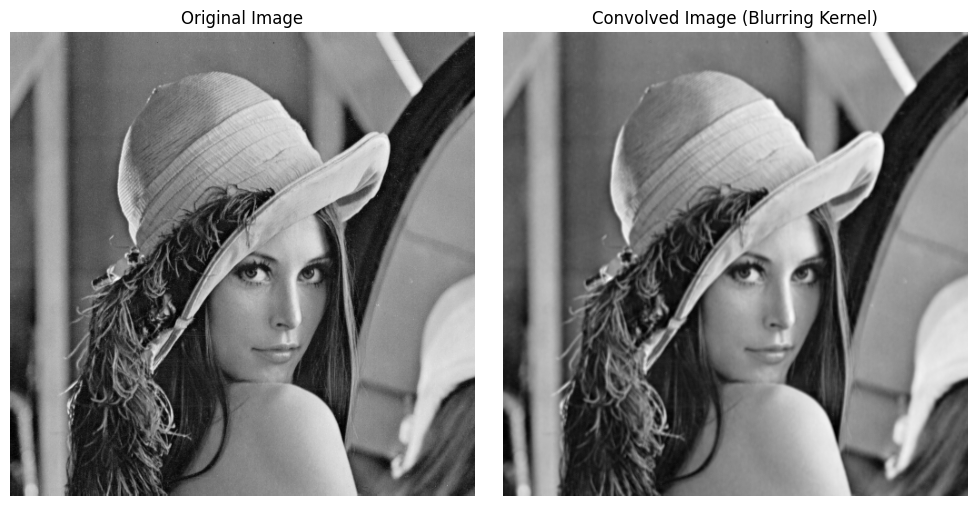

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Define a 3x3 blurring kernel
blur_kernel = np.array([
    [1, 1, 0],
    [1, 0, 1],
    [1, 1, 0]
]) / 9.0

# Apply the convolution function to image_array
convolved_image = conv2d_nopadding(image_array, blur_kernel)

# Display the original and convolved images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(convolved_image, cmap='gray')
plt.title('Convolved Image (Blurring Kernel)')
plt.axis('off')

plt.tight_layout()
plt.show()